In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "3"

In [5]:
import json
import os
import time
from typing import Sequence, Tuple
import numpy as np
import jax
import jax.numpy as jnp
from jaxued.environments.underspecified_env import EnvParams, EnvState, UnderspecifiedEnv
from jaxued.utils import compute_max_mean_returns_epcount, compute_max_mean_returns_epcount_w_idxs
import optax
from flax import struct
from flax.training.train_state import TrainState as BaseTrainState
import flax.linen as nn
from flax.linen.initializers import constant, orthogonal
import distrax
import orbax.checkpoint as ocp
import wandb
from jaxued.environments.maze.env_editor import MazeEditor, Observation, ObservedMazeEditor, ObservedMazeEditorWithGoal
from jaxued.linen import ResetRNN
from jaxued.environments import Maze, MazeRenderer, ObservedMazeRenderer
from jaxued.environments.maze import Level, ObservedLevel
from jaxued.wrappers import AutoReplayWrapper
import chex

import logging
import hydra
from omegaconf import DictConfig, OmegaConf
import matplotlib.pyplot as plt

from jax.profiler import start_trace, stop_trace

In [4]:
from omegaconf import OmegaConf
from hydra import initialize, compose


def load_hydra_config(config_path, config_name):
    # Initialize the Hydra context
    with initialize(config_path=config_path):
        # Compose the configuration
        cfg = compose(config_name=config_name)
        return cfg
    
config_path = "config"  # path to the directory containing the config file
config_name = "main_obs_gen"  # name of the config file without the extension

config = load_hydra_config(config_path, config_name)

if config["num_env_steps"] is not None:
    config["num_updates"] = config["num_env_steps"] // (config["num_train_envs"] * config["num_steps"])

if config['mode'] == 'eval':
    os.environ['WANDB_MODE'] = 'disabled'
    

/tmp/ipykernel_2308168/3239372705.py:7: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with initialize(config_path=config_path):


In [ ]:
# region PPO helper functions    
@struct.dataclass
class TrainState:
    update_count: int
    pro_train_state: BaseTrainState
    critic_train_state: BaseTrainState
    adv_train_state: BaseTrainState

def compute_gae(
    gamma: float,
    lambd: float,
    last_value: chex.Array,
    values: chex.Array,
    rewards: chex.Array,
    dones: chex.Array,
    traj_idxs: chex.Array
) -> Tuple[chex.Array, chex.Array]:
    """This takes in arrays of shape (NUM_STEPS, NUM_ENVS) and returns the advantages and targets.

    Args:
        gamma (float): 
        lambd (float): 
        last_value (chex.Array):  Shape (NUM_ENVS)
        values (chex.Array): Shape (NUM_STEPS, NUM_ENVS)
        rewards (chex.Array): Shape (NUM_STEPS, NUM_ENVS)
        dones (chex.Array): Shape (NUM_STEPS, NUM_ENVS)

    Returns:
        Tuple[chex.Array, chex.Array]: advantages, targets; each of shape (NUM_STEPS, NUM_ENVS)
    """
    def compute_gae_at_timestep(carry, x):
        gae, next_value, cur_idx = carry
        traj_started = cur_idx <= traj_idxs
    
        value, reward, done = x
        delta = reward + gamma * next_value * (1 - done) * traj_started - value
        gae = delta + gamma * lambd * (1 - done) * gae
        return (gae, jnp.where(traj_started, value, next_value), cur_idx - 1), gae

    _, advantages = jax.lax.scan(
        compute_gae_at_timestep,
        (jnp.zeros_like(last_value), last_value, values.shape[0]),
        (values, rewards, dones),
        reverse=True,
        unroll=16,
    )
    return advantages, advantages + values


class ActorCritic(nn.Module):
    action_dim: Sequence[int]
    
    @nn.compact
    def __call__(self, inputs, hidden):
        obs, dones = inputs
        
        img_embed = nn.Conv(16, kernel_size=(3, 3), strides=(1, 1), padding="VALID")(obs.image)
        img_embed = img_embed.reshape(*img_embed.shape[:-3], -1)
        img_embed = nn.relu(img_embed)
        
        dir_embed = jax.nn.one_hot(obs.agent_dir, 4)
        dir_embed = nn.Dense(5, kernel_init=orthogonal(np.sqrt(2)), bias_init=constant(0.0), name="scalar_embed")(dir_embed)
        
        embedding = jnp.append(img_embed, dir_embed, axis=-1)

        hidden, embedding = ResetRNN(nn.OptimizedLSTMCell(features=256))((embedding, dones), initial_carry=hidden)

        actor_mean = nn.Dense(32, kernel_init=orthogonal(2), bias_init=constant(0.0), name="actor0")(embedding)
        actor_mean = nn.tanh(actor_mean)
        actor_mean = nn.Dense(self.action_dim, kernel_init=orthogonal(0.01), bias_init=constant(0.0), name="actor1")(actor_mean)
        pi = distrax.Categorical(logits=actor_mean)

        critic = nn.Dense(32, kernel_init=orthogonal(2), bias_init=constant(0.0), name="critic0")(embedding)
        critic = nn.relu(critic)
        critic = nn.Dense(1, kernel_init=orthogonal(1.0), bias_init=constant(0.0), name="critic1")(critic)

        return hidden, pi, jnp.squeeze(critic, axis=-1)
    
    @staticmethod
    def initialize_carry(batch_dims):
        return nn.OptimizedLSTMCell(features=256).initialize_carry(jax.random.PRNGKey(0), (*batch_dims, 256))


class AdversaryActorCritic(nn.Module):
    # The adversary's network architecture
    action_dim: Sequence[int]
    max_timesteps: int = 50
    
    @nn.compact
    def __call__(self, inputs: Tuple[Observation, chex.Array], hidden):
        obs, dones = inputs
        
        img_embed = nn.Conv(128, kernel_size=(3, 3), strides=(1, 1), padding="VALID")(jnp.concatenate((obs.image, jnp.expand_dims(obs.observation_map, axis=-1), obs.agent_observations), axis=-1))
        img_embed = img_embed.reshape(*img_embed.shape[:-3], -1)
        img_embed = nn.relu(img_embed)
        
        time_value = nn.Embed(self.max_timesteps + 1, 10, name="time_embed", embedding_init=orthogonal(1.0))(jnp.clip(obs.time, None, self.max_timesteps))
        random_z_value = obs.random_z
        embedding = jnp.concatenate((img_embed, time_value, random_z_value, obs.place_goal[..., None]), axis=-1)

        hidden, embedding = ResetRNN(nn.OptimizedLSTMCell(features=256))((embedding, dones), initial_carry=hidden)

        actor_mean = nn.Dense(32, kernel_init=orthogonal(2), bias_init=constant(0.0), name="actor0")(embedding)
        actor_mean = nn.relu(actor_mean)
        actor_mean = nn.Dense(self.action_dim, kernel_init=orthogonal(0.01), bias_init=constant(0.0), name="actor1")(actor_mean)

        # Mask out this
        actor_mean = jnp.where(obs.action_mask, actor_mean, -jnp.inf)
        pi = distrax.Categorical(logits=actor_mean)

        critic = nn.Dense(32, kernel_init=orthogonal(2), bias_init=constant(0.0), name="critic0")(embedding)
        critic = nn.relu(critic)
        critic = nn.Dense(1, kernel_init=orthogonal(1.0), bias_init=constant(0.0), name="critic1")(critic)

        return hidden, pi, jnp.squeeze(critic, axis=-1)
    
    @staticmethod
    def initialize_carry(batch_dims):
        return nn.OptimizedLSTMCell(features=256).initialize_carry(jax.random.PRNGKey(0), (*batch_dims, 256))


class Critic(nn.Module):
    action_dim: Sequence[int]
    
    @nn.compact
    def __call__(self, inputs, hidden):
        obs, dones = inputs
        
        img_embed = nn.Conv(16, kernel_size=(3, 3), strides=(1, 1), padding="VALID")(obs.image)
        img_embed = img_embed.reshape(*img_embed.shape[:-3], -1)
        img_embed = nn.relu(img_embed)
        
        dir_embed = jax.nn.one_hot(obs.agent_dir, 4)
        dir_embed = nn.Dense(5, kernel_init=orthogonal(np.sqrt(2)), bias_init=constant(0.0), name="scalar_embed")(dir_embed)
        
        embedding = jnp.append(img_embed, dir_embed, axis=-1)

        hidden, embedding = ResetRNN(nn.OptimizedLSTMCell(features=256))((embedding, dones), initial_carry=hidden)

        critic = nn.Dense(32, kernel_init=orthogonal(2), bias_init=constant(0.0), name="critic0")(embedding)
        critic = nn.relu(critic)
        critic = nn.Dense(1, kernel_init=orthogonal(1.0), bias_init=constant(0.0), name="critic1")(critic)

        return hidden, jnp.squeeze(critic, axis=-1)
    
    @staticmethod
    def initialize_carry(batch_dims):
        return nn.OptimizedLSTMCell(features=256).initialize_carry(jax.random.PRNGKey(0), (*batch_dims, 256))

In [6]:
env = Maze(max_height=13, max_width=13, agent_view_size=5, normalize_obs=True)
crit_env = Maze(max_height=13, max_width=13, agent_view_size=5, normalize_obs=False, fully_obs=True)
adv_env = ObservedMazeEditorWithGoal(env, random_z_dimensions=config['adv_random_z_dimension'], zero_out_random_z=config['adv_zero_out_random_z'], agents=1)
adv_env_renderer = ObservedMazeRenderer(env, tile_size=8)
env_renderer = MazeRenderer(env, tile_size=8)
env = AutoReplayWrapper(env)
env_params = env.default_params
adv_env_params = adv_env.default_params

rng = jax.random.PRNGKey(14532)
rng, _rng = jax.random.split(rng)

In [7]:
def sample_empty_level():
    w, h = env._env.max_width, env._env.max_height
    return ObservedLevel(
        wall_map=jnp.zeros((h, w), dtype=jnp.bool_),
        observation_map=jnp.zeros((h, w), dtype=jnp.bool_),
        width=w,
        height=h,
        
        # These values don't matter, as the adversary overwrites them.
        goal_pos=jnp.array([0, 0], dtype=jnp.uint32),
        agent_pos=jnp.array([1, 1], dtype=jnp.uint32),
        agent_dir=jnp.array(0, dtype=jnp.uint8),
        goal_placed=jnp.array(False, dtype=jnp.bool_),
    )

def create_train_state(rng):
    def create_inner_train_state(rng, env, env_params, network_cls, prefix, network_kws={}):
        def linear_schedule(count):
            frac = (
                1.0
                - (count // (config[f"{prefix}num_minibatches"] * config[f"{prefix}epoch_ppo"]))
                / config["num_updates"]
            )
            return config[f"{prefix}lr"] * frac
        obs, _ = env.reset_to_level(rng, sample_empty_level(), env_params)
        obs = jax.tree_map(
            lambda x: jnp.repeat(jnp.repeat(x[None, ...], config["num_train_envs"], axis=0)[None, ...], 256, axis=0),
            obs,
        )
        init_x = (obs, jnp.zeros((256, config["num_train_envs"])))
        network = network_cls(env.action_space(env_params).n, **network_kws)
        network_params = network.init(rng, init_x, network_cls.initialize_carry((config["num_train_envs"],)))
        tx = optax.chain(
            optax.clip_by_global_norm(config[f"{prefix}max_grad_norm"]),
            optax.adam(learning_rate=linear_schedule, eps=1e-5),
            # optax.adam(learning_rate=config[f"{prefix}lr"], eps=1e-5),
        )
        return BaseTrainState.create(
            apply_fn=network.apply,
            params=network_params,
            tx=tx,
        )
    rng_pro, rng_crit, rng_adv = jax.random.split(rng, 3)
    return TrainState(
        update_count = 0,
        pro_train_state = create_inner_train_state(rng_pro, env, env_params, ActorCritic, "student_"),
        critic_train_state = create_inner_train_state(rng_crit, crit_env, adv_env_params, Critic, "student_"),
        adv_train_state = create_inner_train_state(rng_adv, adv_env, adv_env_params, AdversaryActorCritic, "adv_", network_kws={"max_timesteps": config["adv_num_steps"]})
    )

In [8]:
rng, _rng = jax.random.split(rng)
train_state = create_train_state(_rng)

# Adv Environment

In [9]:
def sample_trajectories(
    rng: chex.PRNGKey,
    env: UnderspecifiedEnv,
    env_params: EnvParams,
    adv_env: UnderspecifiedEnv,
    adv_env_params: EnvParams,
    train_state: TrainState,
    init_levels: ObservedLevel,
    num_envs: int,
    max_episode_length: int,
    max_adv_episode_length: int,
):

    pro_train_state = train_state.pro_train_state
    adv_train_state = train_state.adv_train_state


    rng, _rng = jax.random.split(rng)
    adv_init_obs, adv_init_env_state = jax.vmap(adv_env.reset_to_level, in_axes=(0, 0, None))(jax.random.split(_rng, num_envs), init_levels, adv_env_params)
    init_student_obs_mask = jnp.ones((num_envs, adv_env.action_space(adv_env_params).n), dtype=jnp.bool_)

    # Create Padded Trajectory accounting for max size of adversary trajectory
    adv_init_traj = (
        adv_init_obs, 
        jnp.zeros(num_envs, dtype=jnp.int32),
        jnp.zeros(num_envs, dtype=jnp.int32),
        jnp.zeros(num_envs, dtype=jnp.bool_),
        jnp.zeros(num_envs, dtype=jnp.float32),
        jnp.zeros(num_envs, dtype=jnp.float32),
        {}
    )

    def pad_traj(input_array: chex.Array):
        return jnp.stack([input_array] + [jnp.zeros_like(input_array)] * (max_adv_episode_length - 1))

    adv_traj_idxs = jnp.zeros(num_envs, dtype=jnp.int32)
    adv_init_traj = jax.tree_map(pad_traj, adv_init_traj)

    # Student Step in Env
    def sample_student_step(carry, _):
        rng, train_state, hstate, obs, env_state, last_done = carry
        rng, rng_action, rng_step = jax.random.split(rng, 3)

        x = jax.tree_map(lambda x: x[None, ...], (obs, last_done))
        hstate, pi, value = train_state.apply_fn(train_state.params, x, hstate)
        action = pi.sample(seed=rng_action)
        log_prob = pi.log_prob(action)
        value, action, log_prob = (
            value.squeeze(0),
            action.squeeze(0),
            log_prob.squeeze(0),
        )

        next_obs, env_state, reward, done, info = jax.vmap(
            env.step, in_axes=(0, 0, 0, None)
        )(jax.random.split(rng_step, num_envs), env_state, action, env_params)

        carry = (rng, train_state, hstate, next_obs, env_state, done)
        return carry, (obs, action, reward, done, log_prob, value, info)

    # Adversary Step in Env
    def sample_adv_step(carry):
        # Env Step that Updates Action Mask
        def env_step(rng, state, action, params, student_obs_mask, student_observations):
            next_obs, env_state, reward, done, info = adv_env.step(rng, state, action, params)
            action_mask = jnp.logical_and(next_obs.action_mask, student_obs_mask)
            return next_obs.replace(action_mask=action_mask, agent_observations=student_observations, place_goal=jnp.array(False, dtype=jnp.bool_)), env_state, reward, done, info

        rng, train_state, hstate, obs, env_state, last_done, student_obs_mask, student_observations, adv_full_traj, adv_traj_idxs = carry
        rng, rng_action, rng_step = jax.random.split(rng, 3)

        # Check which envs still have remaining actions
        keep_gen = ~jnp.all(~obs.action_mask, axis=1)
        
        traj_not_full = adv_traj_idxs < max_adv_episode_length
        keep_gen = jnp.logical_and(keep_gen, traj_not_full)

        x = jax.tree_map(lambda x: x[None, ...], (obs, last_done))
        next_hstate, pi, value = train_state.apply_fn(train_state.params, x, hstate)
        action = pi.sample(seed=rng_action)
        log_prob = pi.log_prob(action)
        value, action, log_prob = (
            value.squeeze(0),
            action.squeeze(0),
            log_prob.squeeze(0),
        )

        next_obs, next_env_state, reward, done, info = jax.vmap(
            env_step, in_axes=(0, 0, 0, None, 0, 0)
        )(jax.random.split(rng_step, num_envs), env_state, action, env_params, student_obs_mask, student_observations)

        traj_step = (obs, action, reward, done, log_prob, value, info)
        
        # Add next trajectory step to the full padded traj if action was available
        def update_traj(full_traj, traj_step):
            def update_at_idx(full_traj, traj_step, idx, keep_gen):
                return jax.lax.cond(keep_gen,
                    lambda : jax.lax.dynamic_update_slice_in_dim(full_traj, traj_step[None, ...], idx, 0),
                    lambda : full_traj
                )
            
            return jax.vmap(
                update_at_idx, in_axes=(1, 0, 0, 0)
            )(full_traj, traj_step, adv_traj_idxs, keep_gen).swapaxes(1, 0)

        adv_full_traj = jax.tree_map(update_traj, adv_full_traj, traj_step)

        # Replace Carry for envs with available actions
        def replace_carry(new, old):
            expanded_keep_gen = jnp.reshape(keep_gen, (keep_gen.shape[0],) + (1,) * (new.ndim - 1))
            return jnp.where(expanded_keep_gen, new, old)
        
        (next_hstate, next_obs, next_env_state, done, adv_traj_idxs) = jax.tree_map(
            replace_carry,
            (next_hstate, next_obs, next_env_state, done, adv_traj_idxs + 1),
            (hstate, obs, env_state, last_done, adv_traj_idxs)
        )
        
        carry = (
            rng, 
            train_state, 
            next_hstate, 
            next_obs, 
            next_env_state, 
            done, 
            student_obs_mask, 
            student_observations,
            adv_full_traj, 
            adv_traj_idxs
        )
        return carry

    (
        rng, adv_train_state, adv_hstate, adv_last_obs, adv_last_env_state, adv_last_done, student_obs_mask, student_observations, adv_full_traj, adv_traj_idxs
    ) = jax.lax.while_loop(
        lambda carry : (carry[-1] < 2).all(),
        sample_adv_step,
        (
            rng,
            adv_train_state,
            AdversaryActorCritic.initialize_carry((num_envs,)),
            adv_init_obs,
            adv_init_env_state,
            jnp.zeros(num_envs, dtype=bool),
            init_student_obs_mask,
            adv_init_obs.agent_observations,
            adv_init_traj,
            adv_traj_idxs
        ),
    )

    # Initialise Student
    rng, _rng = jax.random.split(rng)
    init_obs, init_env_state = jax.vmap(env.reset_to_level, in_axes=(0, 0, None))(jax.random.split(_rng, num_envs), adv_last_env_state.level, env_params)

    pro_carry = (
        pro_train_state, 
        ActorCritic.initialize_carry((num_envs,)), 
        init_obs, 
        init_env_state, 
        jnp.zeros(num_envs, dtype=bool)
    )

    adv_carry = (
        adv_train_state, 
        adv_hstate, 
        adv_last_obs, 
        adv_last_env_state, 
        adv_last_done, 
        student_obs_mask, 
        adv_full_traj, 
        adv_traj_idxs
    )

    # get adversary action 
    def sample_step(carry, _):
        rng, pro_carry, adv_carry = carry

        pro_train_state, pro_hstate, pro_obs, pro_env_state, pro_last_done = pro_carry
        adv_train_state, adv_hstate, _, adv_last_env_state, adv_last_done, student_obs_mask, adv_full_traj, adv_traj_idxs = adv_carry
        adv_last_obs = jax.vmap(adv_env.get_obs, in_axes=(0, 0))(jax.random.split(_rng, num_envs), adv_last_env_state)

        student_observations = pro_obs.agent_observation[..., None]
        student_obs_mask = jnp.concatenate([jnp.logical_or(student_observations[:, :, :, 0], student_observations[:, :, :, 1]).reshape(num_envs, -1)]*3, axis=1)
        action_mask = jnp.logical_and(adv_last_obs.action_mask, student_obs_mask)

        # Prevent Goal Placing on all but the first action of the set
        student_obs_mask = jnp.logical_and(student_obs_mask, jnp.concatenate([jnp.ones((num_envs, adv_env.action_space(adv_env_params).n * 2 // 3)), jnp.zeros((num_envs, adv_env.action_space(adv_env_params).n // 3))], axis=1))

        # Get Protagonist Location
        agent_location = jnp.concatenate([pro_env_state.env_state.agent_dir[:, None], pro_env_state.env_state.agent_pos], axis=-1)

        (
            (rng, adv_train_state, adv_hstate, adv_last_obs, adv_last_env_state, adv_last_done, student_obs_mask, student_observations, adv_full_traj, adv_traj_idxs)
        ) = jax.lax.while_loop(
            lambda carry : ~jnp.logical_or(jnp.all(~carry[3].action_mask, axis=1), ~(carry[9] < max_adv_episode_length)).all(),
            #lambda carry : ~(~carry[3].action_mask).all()
            sample_adv_step,
            (
                rng,
                adv_train_state,
                adv_hstate,
                adv_last_obs.replace(action_mask=action_mask, agent_observations=student_observations),
                adv_last_env_state,
                adv_last_done,
                student_obs_mask,
                student_observations,
                adv_full_traj,
                adv_traj_idxs
            )
        )

        # update student envs
        pro_obs, pro_env_state = jax.vmap(env.update_state_from_level, in_axes=(0, 0))(adv_last_env_state.level, pro_env_state)

        # students act in env
        full_pro_carry, pro_traj_step = sample_student_step(
            (rng, pro_train_state, pro_hstate, pro_obs, pro_env_state, pro_last_done), 
            None
        )
        rng, pro_carry = full_pro_carry[0], full_pro_carry[1:]

        # Return Carry
        adv_carry = (adv_train_state, adv_hstate, adv_last_obs, adv_last_env_state, adv_last_done, student_obs_mask, adv_full_traj, adv_traj_idxs)
        carry = (rng, pro_carry, adv_carry)

        return carry, (pro_traj_step, adv_traj_idxs, agent_location)

    (rng, pro_carry, adv_carry), (pro_traj, adv_traj_idx_array, pro_locations) = jax.lax.scan(
        sample_step, 
        (rng, pro_carry, adv_carry), 
        None, 
        length=max_episode_length
    )

    def get_last_value(carry):
        train_state, hstate, last_obs, _, last_done = carry[:5]
        x = jax.tree_map(lambda x: x[None, ...], (last_obs, last_done))
        _, _, last_value = train_state.apply_fn(train_state.params, x, hstate)
        return last_value

    last_values = get_last_value(pro_carry).squeeze(0), get_last_value(adv_carry).squeeze(0)

    last_pro_env_state = pro_carry[3]
    last_agent_location = jnp.concatenate([last_pro_env_state.env_state.agent_dir[:, None], last_pro_env_state.env_state.agent_pos], axis=-1)    

    return rng, (pro_carry[:4], adv_carry[:4]), (pro_traj, adv_carry[6:]), last_values, adv_traj_idx_array, jnp.concatenate([pro_locations, last_agent_location[None, ...]], axis=0)

In [9]:
def sample_trajectories_new(
    rng: chex.PRNGKey,
    env: UnderspecifiedEnv,
    env_params: EnvParams,
    adv_env: UnderspecifiedEnv,
    adv_env_params: EnvParams,
    train_state: TrainState,
    init_levels: ObservedLevel,
    num_envs: int,
    max_episode_length: int,
    max_adv_episode_length: int,
):
    pro_train_state = train_state.pro_train_state
    adv_train_state = train_state.adv_train_state


    rng, _rng = jax.random.split(rng)
    adv_init_obs, adv_init_env_state = jax.vmap(adv_env.reset_to_level, in_axes=(0, 0, None))(jax.random.split(_rng, num_envs), init_levels, adv_env_params)
    init_student_obs_mask = jnp.ones((num_envs, adv_env.action_space(adv_env_params).n), dtype=jnp.bool_)

    # Create Padded Trajectory accounting for max size of adversary trajectory
    adv_init_traj = (
        adv_init_obs, 
        jnp.zeros(num_envs, dtype=jnp.int32),
        jnp.zeros(num_envs, dtype=jnp.int32),
        jnp.zeros(num_envs, dtype=jnp.bool_),
        jnp.zeros(num_envs, dtype=jnp.float32),
        jnp.zeros(num_envs, dtype=jnp.float32),
        {}
    )

    def pad_traj(input_array: chex.Array):
        return jnp.stack([input_array] + [jnp.zeros_like(input_array)] * (max_adv_episode_length - 1))

    adv_traj_idxs = jnp.zeros(num_envs, dtype=jnp.int32)
    adv_init_traj = jax.tree_map(pad_traj, adv_init_traj)

    # Student Step in Env
    def sample_student_step(carry, _):
        rng, train_state, hstate, obs, env_state, last_done = carry
        rng, rng_action, rng_step = jax.random.split(rng, 3)

        x = jax.tree_map(lambda x: x[None, ...], (obs, last_done))
        hstate, pi, value = train_state.apply_fn(train_state.params, x, hstate)
        action = pi.sample(seed=rng_action)
        log_prob = pi.log_prob(action)
        value, action, log_prob = (
            value.squeeze(0),
            action.squeeze(0),
            log_prob.squeeze(0),
        )

        next_obs, env_state, reward, done, info = jax.vmap(
            env.step, in_axes=(0, 0, 0, None)
        )(jax.random.split(rng_step, num_envs), env_state, action, env_params)

        carry = (rng, train_state, hstate, next_obs, env_state, done)
        return carry, (obs, action, reward, done, log_prob, value, info)

    # Adversary Step in Env
    def sample_adv_step(carry):
        rng, train_state, hstate, obs, env_state, last_done, student_obs_mask, student_observations, adv_full_traj, adv_traj_idxs = carry
        rng, rng_split = jax.random.split(rng)

        step_carry = hstate, obs, env_state, last_done, student_obs_mask, student_observations, adv_traj_idxs

        def take_unfinished_env_step(step_carry, adv_partial_traj, rng):
            _, obs, _, _, _, _, adv_traj_idxs = step_carry

            keep_gen = ~jnp.all(~obs.action_mask)
            traj_not_full = adv_traj_idxs < max_adv_episode_length
            keep_gen = jnp.logical_and(keep_gen, traj_not_full)

            def env_step():
                hstate, obs, env_state, last_done, student_obs_mask, student_observations, adv_traj_idxs = step_carry
                rng_action, rng_step = jax.random.split(rng)

                hstate = jax.tree_map(lambda x: x[None, ...], hstate)
                x = jax.tree_map(lambda x: x[None, None, ...], (obs, last_done))
                next_hstate, pi, value = train_state.apply_fn(train_state.params, x, hstate)
                action = pi.sample(seed=rng_action)
                log_prob = pi.log_prob(action)
                value, action, log_prob = (
                    value.squeeze(),
                    action.squeeze(),
                    log_prob.squeeze(),
                )

                next_hstate = jax.tree_map(lambda x : x.squeeze(0), next_hstate)

                next_obs, next_env_state, reward, done, info = adv_env.step(rng_step, env_state, action, env_params)
                action_mask = jnp.logical_and(next_obs.action_mask, student_obs_mask)
                next_obs = next_obs.replace(action_mask=action_mask, agent_observations=student_observations, place_goal=jnp.array(False, dtype=jnp.bool_))
            
                traj_step = (obs, action, reward, done, log_prob, value, info)

                next_adv_partial_traj = jax.tree_map(
                    lambda partial_traj, traj_step : jax.lax.dynamic_update_slice_in_dim(partial_traj, traj_step[None, ...], adv_traj_idxs, 0),
                    adv_partial_traj, traj_step)
                
                next_step_carry = next_hstate, next_obs, next_env_state, done, student_obs_mask, student_observations, adv_traj_idxs + 1

                return next_step_carry, next_adv_partial_traj
            
            return jax.lax.cond(keep_gen,
                env_step,
                lambda : (step_carry, adv_partial_traj)
            )
        
        (next_hstate, next_obs, next_env_state, done, _, _, adv_traj_idxs), adv_full_traj = jax.vmap(
            take_unfinished_env_step,
            in_axes=(0, 1, 0)
        )(step_carry, adv_full_traj, jax.random.split(rng_split, num_envs))

        adv_full_traj = jax.tree_map(lambda x : x.swapaxes(0, 1), adv_full_traj)

        carry = (
            rng, 
            train_state, 
            next_hstate, 
            next_obs, 
            next_env_state, 
            done, 
            student_obs_mask, 
            student_observations,
            adv_full_traj, 
            adv_traj_idxs
        )
        return carry

    (
        rng, adv_train_state, adv_hstate, adv_last_obs, adv_last_env_state, adv_last_done, student_obs_mask, student_observations, adv_full_traj, adv_traj_idxs
    ) = jax.lax.while_loop(
        lambda carry : (carry[-1] < 2).all(),
        sample_adv_step,
        (
            rng,
            adv_train_state,
            AdversaryActorCritic.initialize_carry((num_envs,)),
            adv_init_obs,
            adv_init_env_state,
            jnp.zeros(num_envs, dtype=bool),
            init_student_obs_mask,
            adv_init_obs.agent_observations,
            adv_init_traj,
            adv_traj_idxs
        ),
    )

    # Initialise Student
    rng, _rng = jax.random.split(rng)
    init_obs, init_env_state = jax.vmap(env.reset_to_level, in_axes=(0, 0, None))(jax.random.split(_rng, num_envs), adv_last_env_state.level, env_params)

    pro_carry = (
        pro_train_state, 
        ActorCritic.initialize_carry((num_envs,)), 
        init_obs, 
        init_env_state, 
        jnp.zeros(num_envs, dtype=bool)
    )

    adv_carry = (
        adv_train_state, 
        adv_hstate, 
        adv_last_obs, 
        adv_last_env_state, 
        adv_last_done, 
        student_obs_mask, 
        adv_full_traj, 
        adv_traj_idxs
    )

    # get adversary action 
    def sample_step(carry, _):
        rng, pro_carry, adv_carry = carry

        pro_train_state, pro_hstate, pro_obs, pro_env_state, pro_last_done = pro_carry
        adv_train_state, adv_hstate, _, adv_last_env_state, adv_last_done, student_obs_mask, adv_full_traj, adv_traj_idxs = adv_carry
        adv_last_obs = jax.vmap(adv_env.get_obs, in_axes=(0, 0))(jax.random.split(_rng, num_envs), adv_last_env_state)

        student_observations = pro_obs.agent_observation[..., None]
        student_obs_mask = jnp.concatenate([jnp.logical_or(student_observations[:, :, :, 0], student_observations[:, :, :, 1]).reshape(num_envs, -1)]*3, axis=1)
        action_mask = jnp.logical_and(adv_last_obs.action_mask, student_obs_mask)

        # Prevent Goal Placing on all but the first action of the set
        student_obs_mask = jnp.logical_and(student_obs_mask, jnp.concatenate([jnp.ones((num_envs, adv_env.action_space(adv_env_params).n * 2 // 3)), jnp.zeros((num_envs, adv_env.action_space(adv_env_params).n // 3))], axis=1))

        # Get Protagonist Location
        agent_location = jnp.concatenate([pro_env_state.env_state.agent_dir[:, None], pro_env_state.env_state.agent_pos], axis=-1)

        (
            (rng, adv_train_state, adv_hstate, adv_last_obs, adv_last_env_state, adv_last_done, student_obs_mask, student_observations, adv_full_traj, adv_traj_idxs)
        ) = jax.lax.while_loop(
            lambda carry : ~jnp.logical_or(jnp.all(~carry[3].action_mask, axis=1), ~(carry[9] < max_adv_episode_length)).all(),
            #lambda carry : ~(~carry[3].action_mask).all()
            sample_adv_step,
            (
                rng,
                adv_train_state,
                adv_hstate,
                adv_last_obs.replace(action_mask=action_mask, agent_observations=student_observations),
                adv_last_env_state,
                adv_last_done,
                student_obs_mask,
                student_observations,
                adv_full_traj,
                adv_traj_idxs
            )
        )

        # update student envs
        pro_obs, pro_env_state = jax.vmap(env.update_state_from_level, in_axes=(0, 0))(adv_last_env_state.level, pro_env_state)

        # students act in env
        full_pro_carry, pro_traj_step = sample_student_step(
            (rng, pro_train_state, pro_hstate, pro_obs, pro_env_state, pro_last_done), 
            None
        )
        rng, pro_carry = full_pro_carry[0], full_pro_carry[1:]

        # Return Carry
        adv_carry = (adv_train_state, adv_hstate, adv_last_obs, adv_last_env_state, adv_last_done, student_obs_mask, adv_full_traj, adv_traj_idxs)
        carry = (rng, pro_carry, adv_carry)

        return carry, (pro_traj_step, adv_traj_idxs, agent_location)

    (rng, pro_carry, adv_carry), (pro_traj, adv_traj_idx_array, pro_locations) = jax.lax.scan(
        sample_step, 
        (rng, pro_carry, adv_carry), 
        None, 
        length=max_episode_length
    )

    def get_last_value(carry):
        train_state, hstate, last_obs, _, last_done = carry[:5]
        x = jax.tree_map(lambda x: x[None, ...], (last_obs, last_done))
        _, _, last_value = train_state.apply_fn(train_state.params, x, hstate)
        return last_value

    last_values = get_last_value(pro_carry).squeeze(0), get_last_value(adv_carry).squeeze(0)

    last_pro_env_state = pro_carry[3]
    last_agent_location = jnp.concatenate([last_pro_env_state.env_state.agent_dir[:, None], last_pro_env_state.env_state.agent_pos], axis=-1)    

    return rng, (pro_carry[:4], adv_carry[:4]), (pro_traj, adv_carry[6:]), last_values, adv_traj_idx_array, jnp.concatenate([pro_locations, last_agent_location[None, ...]], axis=0)

In [62]:
def sample_trajectories_new_new(
    rng: chex.PRNGKey,
    env: UnderspecifiedEnv,
    env_params: EnvParams,
    adv_env: UnderspecifiedEnv,
    adv_env_params: EnvParams,
    train_state: TrainState,
    init_levels: ObservedLevel,
    num_envs: int,
    max_episode_length: int,
    max_adv_episode_length: int,
):
    pro_train_state = train_state.pro_train_state
    adv_train_state = train_state.adv_train_state


    rng, _rng = jax.random.split(rng)
    adv_init_obs, adv_init_env_state = jax.vmap(adv_env.reset_to_level, in_axes=(0, 0, None))(jax.random.split(_rng, num_envs), init_levels, adv_env_params)
    init_student_obs_mask = jnp.ones((num_envs, adv_env.action_space(adv_env_params).n), dtype=jnp.bool_)

    # Create Padded Trajectory accounting for max size of adversary trajectory
    adv_init_traj = (
        adv_init_obs, 
        jnp.zeros(num_envs, dtype=jnp.int32),
        jnp.zeros(num_envs, dtype=jnp.int32),
        jnp.zeros(num_envs, dtype=jnp.bool_),
        jnp.zeros(num_envs, dtype=jnp.float32),
        jnp.zeros(num_envs, dtype=jnp.float32),
        {}
    )

    def pad_traj(input_array: chex.Array):
        return jnp.stack([input_array] + [jnp.zeros_like(input_array)] * (max_adv_episode_length - 1))

    adv_traj_idxs = jnp.zeros(num_envs, dtype=jnp.int32)
    adv_init_traj = jax.tree_map(pad_traj, adv_init_traj)

    # Student Step in Env
    def sample_student_step(carry, _):
        rng, train_state, hstate, obs, env_state, last_done = carry
        rng, rng_action, rng_step = jax.random.split(rng, 3)

        x = jax.tree_map(lambda x: x[None, ...], (obs, last_done))
        hstate, pi, value = train_state.apply_fn(train_state.params, x, hstate)
        action = pi.sample(seed=rng_action)
        log_prob = pi.log_prob(action)
        value, action, log_prob = (
            value.squeeze(0),
            action.squeeze(0),
            log_prob.squeeze(0),
        )

        next_obs, env_state, reward, done, info = jax.vmap(
            env.step, in_axes=(0, 0, 0, None)
        )(jax.random.split(rng_step, num_envs), env_state, action, env_params)

        carry = (rng, train_state, hstate, next_obs, env_state, done)
        return carry, (obs, action, reward, done, log_prob, value, info)

    # Adversary Step in Env
    def sample_adv_step(carry):
        rng, train_state, hstate, obs, env_state, last_done, student_obs_mask, student_observations, adv_full_traj, adv_traj_idxs = carry
        rng, rng_split = jax.random.split(rng)

        keep_gen = ~jnp.all(~obs.action_mask)
        traj_not_full = adv_traj_idxs < max_adv_episode_length
        keep_gen = jnp.logical_and(keep_gen, traj_not_full)

        step_carry = hstate, obs, env_state, last_done, student_obs_mask, student_observations, adv_traj_idxs

        def take_keepgen_env_step(step_carry, keep_gen, rng):
            _, obs, _, _, _, _, adv_traj_idxs = step_carry

            def env_step():
                hstate, obs, env_state, last_done, student_obs_mask, student_observations, adv_traj_idxs = step_carry
                rng_action, rng_step = jax.random.split(rng)

                hstate = jax.tree_map(lambda x: x[None, ...], hstate)
                x = jax.tree_map(lambda x: x[None, None, ...], (obs, last_done))
                next_hstate, pi, value = train_state.apply_fn(train_state.params, x, hstate)
                action = pi.sample(seed=rng_action)
                log_prob = pi.log_prob(action)
                value, action, log_prob = (
                    value.squeeze(),
                    action.squeeze(),
                    log_prob.squeeze(),
                )

                next_hstate = jax.tree_map(lambda x : x.squeeze(0), next_hstate)

                next_obs, next_env_state, reward, done, info = adv_env.step(rng_step, env_state, action, env_params)
                action_mask = jnp.logical_and(next_obs.action_mask, student_obs_mask)
                next_obs = next_obs.replace(action_mask=action_mask, agent_observations=student_observations, place_goal=jnp.array(False, dtype=jnp.bool_))
            
                traj_step = (obs, action, reward, done, log_prob, value, info)
                
                next_step_carry = next_hstate, next_obs, next_env_state, done, student_obs_mask, student_observations, adv_traj_idxs + 1

                return next_step_carry, traj_step
            
            def empty_step():
                return step_carry, (obs, 0, 0, False, 0., 0., {})
            
            return jax.lax.cond(keep_gen,
                env_step,
                empty_step
            )
        
        (next_hstate, next_obs, next_env_state, done, _, _, adv_traj_idxs), traj_step = jax.vmap(
            take_keepgen_env_step,
            in_axes=(0, 0, 0)
        )(step_carry, keep_gen, jax.random.split(rng_split, num_envs))

        # Add next trajectory step to the full padded traj if action was available
        def update_traj(full_traj, traj_step):
            def update_at_idx(full_traj, traj_step, idx, keep_gen):
                return jax.lax.cond(keep_gen,
                    lambda : jax.lax.dynamic_update_slice_in_dim(full_traj, traj_step[None, ...], idx, 0),
                    lambda : full_traj
                )
            
            return jax.vmap(
                update_at_idx, in_axes=(1, 0, 0, 0)
            )(full_traj, traj_step, adv_traj_idxs, keep_gen).swapaxes(1, 0)

        adv_full_traj = jax.tree_map(update_traj, adv_full_traj, traj_step)


        carry = (
            rng, 
            train_state, 
            next_hstate, 
            next_obs, 
            next_env_state, 
            done, 
            student_obs_mask, 
            student_observations,
            adv_full_traj, 
            adv_traj_idxs
        )
        return carry

    (
        rng, adv_train_state, adv_hstate, adv_last_obs, adv_last_env_state, adv_last_done, student_obs_mask, student_observations, adv_full_traj, adv_traj_idxs
    ) = jax.lax.while_loop(
        lambda carry : (carry[-1] < 2).all(),
        sample_adv_step,
        (
            rng,
            adv_train_state,
            AdversaryActorCritic.initialize_carry((num_envs,)),
            adv_init_obs,
            adv_init_env_state,
            jnp.zeros(num_envs, dtype=bool),
            init_student_obs_mask,
            adv_init_obs.agent_observations,
            adv_init_traj,
            adv_traj_idxs
        ),
    )

    # Initialise Student
    rng, _rng = jax.random.split(rng)
    init_obs, init_env_state = jax.vmap(env.reset_to_level, in_axes=(0, 0, None))(jax.random.split(_rng, num_envs), adv_last_env_state.level, env_params)

    pro_carry = (
        pro_train_state, 
        ActorCritic.initialize_carry((num_envs,)), 
        init_obs, 
        init_env_state, 
        jnp.zeros(num_envs, dtype=bool)
    )

    adv_carry = (
        adv_train_state, 
        adv_hstate, 
        adv_last_obs, 
        adv_last_env_state, 
        adv_last_done, 
        student_obs_mask, 
        adv_full_traj, 
        adv_traj_idxs
    )

    # get adversary action 
    def sample_step(carry, _):
        rng, pro_carry, adv_carry = carry

        pro_train_state, pro_hstate, pro_obs, pro_env_state, pro_last_done = pro_carry
        adv_train_state, adv_hstate, _, adv_last_env_state, adv_last_done, student_obs_mask, adv_full_traj, adv_traj_idxs = adv_carry
        adv_last_obs = jax.vmap(adv_env.get_obs, in_axes=(0, 0))(jax.random.split(_rng, num_envs), adv_last_env_state)

        student_observations = pro_obs.agent_observation[..., None]
        student_obs_mask = jnp.concatenate([jnp.logical_or(student_observations[:, :, :, 0], student_observations[:, :, :, 1]).reshape(num_envs, -1)]*3, axis=1)
        action_mask = jnp.logical_and(adv_last_obs.action_mask, student_obs_mask)

        # Prevent Goal Placing on all but the first action of the set
        student_obs_mask = jnp.logical_and(student_obs_mask, jnp.concatenate([jnp.ones((num_envs, adv_env.action_space(adv_env_params).n * 2 // 3)), jnp.zeros((num_envs, adv_env.action_space(adv_env_params).n // 3))], axis=1))

        # Get Protagonist Location
        agent_location = jnp.concatenate([pro_env_state.env_state.agent_dir[:, None], pro_env_state.env_state.agent_pos], axis=-1)

        (
            (rng, adv_train_state, adv_hstate, adv_last_obs, adv_last_env_state, adv_last_done, student_obs_mask, student_observations, adv_full_traj, adv_traj_idxs)
        ) = jax.lax.while_loop(
            lambda carry : ~jnp.logical_or(jnp.all(~carry[3].action_mask, axis=1), ~(carry[9] < max_adv_episode_length)).all(),
            #lambda carry : ~(~carry[3].action_mask).all()
            sample_adv_step,
            (
                rng,
                adv_train_state,
                adv_hstate,
                adv_last_obs.replace(action_mask=action_mask, agent_observations=student_observations),
                adv_last_env_state,
                adv_last_done,
                student_obs_mask,
                student_observations,
                adv_full_traj,
                adv_traj_idxs
            )
        )

        # update student envs
        pro_obs, pro_env_state = jax.vmap(env.update_state_from_level, in_axes=(0, 0))(adv_last_env_state.level, pro_env_state)

        # students act in env
        full_pro_carry, pro_traj_step = sample_student_step(
            (rng, pro_train_state, pro_hstate, pro_obs, pro_env_state, pro_last_done), 
            None
        )
        rng, pro_carry = full_pro_carry[0], full_pro_carry[1:]

        # Return Carry
        adv_carry = (adv_train_state, adv_hstate, adv_last_obs, adv_last_env_state, adv_last_done, student_obs_mask, adv_full_traj, adv_traj_idxs)
        carry = (rng, pro_carry, adv_carry)

        return carry, (pro_traj_step, adv_traj_idxs, agent_location)

    (rng, pro_carry, adv_carry), (pro_traj, adv_traj_idx_array, pro_locations) = jax.lax.scan(
        sample_step, 
        (rng, pro_carry, adv_carry), 
        None, 
        length=max_episode_length
    )

    def get_last_value(carry):
        train_state, hstate, last_obs, _, last_done = carry[:5]
        x = jax.tree_map(lambda x: x[None, ...], (last_obs, last_done))
        _, _, last_value = train_state.apply_fn(train_state.params, x, hstate)
        return last_value

    last_values = get_last_value(pro_carry).squeeze(0), get_last_value(adv_carry).squeeze(0)

    last_pro_env_state = pro_carry[3]
    last_agent_location = jnp.concatenate([last_pro_env_state.env_state.agent_dir[:, None], last_pro_env_state.env_state.agent_pos], axis=-1)    

    return rng, (pro_carry[:4], adv_carry[:4]), (pro_traj, adv_carry[6:]), last_values, adv_traj_idx_array, jnp.concatenate([pro_locations, last_agent_location[None, ...]], axis=0)

In [10]:
def masked_mean(arr, mask):
    return jnp.sum(arr * mask) / jnp.sum(mask)

def masked_std(arr, mask):
    mean = masked_mean(arr, mask)
    var = jnp.sum(mask*(arr - mean)**2)/jnp.sum(mask)
    return jnp.sqrt(var)

def update_actor_critic_rnn(
    rng: chex.PRNGKey,
    train_state: TrainState,
    init_hstate: chex.ArrayTree,
    batch: chex.ArrayTree,
    num_envs: int,
    n_steps: int,
    n_minibatch: int,
    n_epochs: int,
    clip_eps: float,
    entropy_coeff: float,
    critic_coeff: float,
    update_grad: bool=True,
) -> Tuple[Tuple[chex.PRNGKey, TrainState], chex.ArrayTree]:
    """This function takes in a rollout, and PPO hyperparameters, and updates the train state.

    Args:
        rng (chex.PRNGKey): 
        train_state (TrainState): 
        init_hstate (chex.ArrayTree): 
        batch (chex.ArrayTree): obs, actions, dones, log_probs, values, targets, advantages
        num_envs (int): 
        n_steps (int): 
        n_minibatch (int): 
        n_epochs (int): 
        clip_eps (float): 
        entropy_coeff (float): 
        critic_coeff (float): 
        update_grad (bool, optional): If False, the train state does not actually get updated. Defaults to True.

    Returns:
        Tuple[Tuple[chex.PRNGKey, TrainState], chex.ArrayTree]: It returns a new rng, the updated train_state, and the losses. The losses have structure (loss, (l_vf, l_clip, entropy))
    """
    obs, actions, dones, log_probs, values, targets, advantages, update_mask = batch
    last_dones = jnp.roll(dones, 1, axis=0).at[0].set(False)
    batch = obs, actions, last_dones, log_probs, values, targets, advantages, update_mask
    
    def update_epoch(carry, _):
        def update_minibatch(train_state, minibatch):
            init_hstate, obs, actions, last_dones, log_probs, values, targets, advantages, update_mask = minibatch
            
            def loss_fn(params):
                _, pi, values_pred = train_state.apply_fn(params, (obs, last_dones), init_hstate)
                log_probs_pred = pi.log_prob(actions)
                entropy = masked_mean(pi.entropy(), update_mask)

                ratio = jnp.exp(log_probs_pred - log_probs)
                A = (advantages - masked_mean(advantages, update_mask)) / (masked_std(advantages, update_mask) + 1e-5)
                l_clip = masked_mean((-jnp.minimum(ratio * A, jnp.clip(ratio, 1 - clip_eps, 1 + clip_eps) * A)), update_mask)

                values_pred_clipped = values + (values_pred - values).clip(-clip_eps, clip_eps)
                l_vf = masked_mean(0.5 * jnp.maximum((values_pred - targets) ** 2, (values_pred_clipped - targets) ** 2), update_mask)

                loss = l_clip + critic_coeff * l_vf - entropy_coeff * entropy

                return loss, (l_vf, l_clip, entropy)

            grad_fn = jax.value_and_grad(loss_fn, has_aux=True)
            loss, grads = grad_fn(train_state.params)
            if update_grad:
                train_state = train_state.apply_gradients(grads=grads)
            return train_state, loss

        rng, train_state = carry
        rng, rng_perm = jax.random.split(rng)
        permutation = jax.random.permutation(rng_perm, num_envs)
        minibatches = (
            jax.tree_map(
                lambda x: jnp.take(x, permutation, axis=0)
                .reshape(n_minibatch, -1, *x.shape[1:]),
                init_hstate,
            ),
            *jax.tree_map(
                lambda x: jnp.take(x, permutation, axis=1)
                .reshape(x.shape[0], n_minibatch, -1, *x.shape[2:])
                .swapaxes(0, 1),
                batch,
            ),
        )
        train_state, losses = jax.lax.scan(update_minibatch, train_state, minibatches)
        return (rng, train_state), losses

    return jax.lax.scan(update_epoch, (rng, train_state), None, n_epochs)

def update(rng, train_state, init_hstate, rollout, prefix):
    # Returns: (rng, train_state), losses
    return update_actor_critic_rnn(
        rng,
        train_state,
        init_hstate,
        rollout,
        config["num_train_envs"],
        config[f"{prefix}num_steps"],
        config[f"{prefix}num_minibatches"],
        config[f"{prefix}epoch_ppo"],
        config[f"{prefix}clip_eps"],
        config[f"{prefix}entropy_coeff"],
        config[f"{prefix}critic_coeff"],
        update_grad=True,
    )

In [11]:
def update_critic_rnn(
    rng: chex.PRNGKey,
    train_state: TrainState,
    init_hstate: chex.ArrayTree,
    batch: chex.ArrayTree,
    num_envs: int,
    n_steps: int,
    n_minibatch: int,
    n_epochs: int,
    clip_eps: float,
    update_grad: bool=True,
) -> Tuple[Tuple[chex.PRNGKey, TrainState], chex.ArrayTree]:
    """This function takes in a rollout, and PPO hyperparameters, and updates the train state.

    Args:
        rng (chex.PRNGKey): 
        train_state (TrainState): 
        init_hstate (chex.ArrayTree): 
        batch (chex.ArrayTree): obs, actions, dones, log_probs, values, targets, advantages
        num_envs (int): 
        n_steps (int): 
        n_minibatch (int): 
        n_epochs (int): 
        clip_eps (float): 
        entropy_coeff (float): 
        critic_coeff (float): 
        update_grad (bool, optional): If False, the train state does not actually get updated. Defaults to True.

    Returns:
        Tuple[Tuple[chex.PRNGKey, TrainState], chex.ArrayTree]: It returns a new rng, the updated train_state, and the losses. The losses have structure (loss, (l_vf, l_clip, entropy))
    """
    obs, dones, values, targets = batch
    last_dones = jnp.roll(dones, 1, axis=0).at[0].set(False)
    batch = obs, last_dones, values, targets
    
    def update_epoch(carry, _):
        def update_minibatch(train_state, minibatch):
            init_hstate, obs, last_dones, values, targets = minibatch
            
            def loss_fn(params):
                _, values_pred = train_state.apply_fn(params, (obs, last_dones), init_hstate)

                values_pred_clipped = values + (values_pred - values).clip(-clip_eps, clip_eps)
                l_vf = (0.5 * jnp.maximum((values_pred - targets) ** 2, (values_pred_clipped - targets) ** 2)).mean()

                loss = l_vf

                return loss, (l_vf)

            grad_fn = jax.value_and_grad(loss_fn, has_aux=True)
            loss, grads = grad_fn(train_state.params)
            if update_grad:
                train_state = train_state.apply_gradients(grads=grads)
            return train_state, loss

        rng, train_state = carry
        rng, rng_perm = jax.random.split(rng)
        permutation = jax.random.permutation(rng_perm, num_envs)
        minibatches = (
            jax.tree_map(
                lambda x: jnp.take(x, permutation, axis=0)
                .reshape(n_minibatch, -1, *x.shape[1:]),
                init_hstate,
            ),
            *jax.tree_map(
                lambda x: jnp.take(x, permutation, axis=1)
                .reshape(x.shape[0], n_minibatch, -1, *x.shape[2:])
                .swapaxes(0, 1),
                batch,
            ),
        )
        train_state, losses = jax.lax.scan(update_minibatch, train_state, minibatches)
        return (rng, train_state), losses

    return jax.lax.scan(update_epoch, (rng, train_state), None, n_epochs)

def update_critic(rng, train_state, init_hstate, rollout):
    # Returns: (rng, train_state), losses
    return update_critic_rnn(
        rng,
        train_state,
        init_hstate,
        rollout,
        config["num_train_envs"],
        config["student_num_steps"],
        config["student_num_minibatches"],
        config["student_epoch_ppo"],
        config["student_clip_eps"],
        update_grad=True,
    )

In [12]:
def get_rollout(traj, traj_idxs, last_value, prefix):
    obs, actions, rewards, dones, log_probs, values, info = traj
    advantages, targets = compute_gae(config[f"{prefix}gamma"], config[f"{prefix}gae_lambda"], last_value, values, rewards, dones, traj_idxs)
    update_mask = jnp.tile(jnp.arange(actions.shape[0])[:, None], (1, actions.shape[1])) < traj_idxs
    return (obs, actions, dones, log_probs, values, targets, advantages, update_mask), (dones, rewards)

In [13]:
# Initialise Levels
empty_levels = jax.tree_map(lambda x: jnp.array([x]).repeat(config["num_train_envs"], axis=0), sample_empty_level())

rng, (pro_carry, adv_carry), (pro_traj, (adv_traj, adv_traj_idxs)), (pro_last_value, adv_last_value), adv_traj_idx_array, pro_locations = sample_trajectories(
    rng,
    env,
    env_params,
    adv_env,
    adv_env_params,
    train_state,
    empty_levels,
    config["num_train_envs"],
    config["student_num_steps"],
    config["adv_num_steps"]
)

In [14]:
obs_pro_locations = pro_traj[0].agent_location

last_pro_env_state = pro_carry[3]
last_agent_location = jnp.concatenate([last_pro_env_state.env_state.agent_dir[:, None], last_pro_env_state.env_state.agent_pos], axis=-1)  

obs_pro_locations = jnp.concatenate([obs_pro_locations, last_agent_location[None, ...]], axis=0)

In [15]:
(pro_locations ==  obs_pro_locations).all()

Array(True, dtype=bool)

In [16]:
jnp.concatenate((adv_traj[0].image, adv_traj[0].observation_map[..., None], adv_traj[0].agent_observations), axis=-1)

Array([[[[[ 1,  0,  0,  0,  1],
          [ 1,  0,  0,  0,  1],
          [ 1,  0,  0,  0,  1],
          ...,
          [ 1,  0,  0,  0,  1],
          [ 1,  0,  0,  0,  1],
          [ 1,  0,  0,  0,  1]],

         [[ 1,  0,  0,  0,  1],
          [ 1,  0,  0,  0,  1],
          [ 1,  0,  0,  0,  1],
          ...,
          [ 1,  0,  0,  0,  1],
          [ 1,  0,  0,  0,  1],
          [ 1,  0,  0,  0,  1]],

         [[ 1,  0,  0,  0,  1],
          [ 1,  0,  0,  0,  1],
          [ 1,  0,  0,  0,  1],
          ...,
          [ 1,  0,  0,  0,  1],
          [ 1,  0,  0,  0,  1],
          [ 1,  0,  0,  0,  1]],

         ...,

         [[ 1,  0,  0,  0,  1],
          [ 1,  0,  0,  0,  1],
          [ 1,  0,  0,  0,  1],
          ...,
          [ 1,  0,  0,  0,  1],
          [ 1,  0,  0,  0,  1],
          [ 1,  0,  0,  0,  1]],

         [[ 1,  0,  0,  0,  1],
          [ 1,  0,  0,  0,  1],
          [ 1,  0,  0,  0,  1],
          ...,
          [ 1,  0,  0,  0,  1],
      

# Optimal Regret

In [17]:
def compute_min_steps_to_goal(level):
    wall_values = jnp.repeat(jnp.where(level.wall_map, jnp.inf, -jnp.inf)[None, ...], 4, axis=0)
    #wall_values = jnp.repeat(jnp.where(jnp.logical_or(level.wall_map, ~level.observation_map), jnp.inf, -jnp.inf)[None, ...], 4, axis=0)
    max_height, max_width = level.wall_map.shape
    
    def compute_next(values):
        fwd_values = jnp.array([
            jnp.roll(values[0], -1, axis=1).astype(float).at[:,-1].set(jnp.inf),
            jnp.roll(values[1], -1, axis=0).astype(float).at[-1,:].set(jnp.inf),
            jnp.roll(values[2], 1, axis=1).astype(float).at[:,0].set(jnp.inf),
            jnp.roll(values[3], 1, axis=0).astype(float).at[0,:].set(jnp.inf),
        ])
        new_values = jnp.empty_like(values)
        for i in range(4):
            new_values = new_values.at[i].set(jnp.min(
                jnp.array([values[i], values[i-1] + 1, values[(i+1)%4] + 1, fwd_values[i] + 1]), axis=0
            ))
        return jnp.maximum(new_values, wall_values)
    
    def cond_fn(carry):
        values, next_values = carry
        return jnp.any(values != next_values)
    
    def body_fn(carry):
        _, values = carry
        return values, compute_next(values)
    
    values = jnp.full((4, max_height, max_width), jnp.inf)
    values = jax.lax.select(level.goal_placed, values.at[:, level.goal_pos[1], level.goal_pos[0]].set(0), values)
    return jax.lax.while_loop(cond_fn, body_fn, (values, compute_next(values)))[0]

In [18]:
def get_agent_min_steps_to_goal(env_state, agent_locations):
    all_optimal_distances = compute_min_steps_to_goal(env_state.level).swapaxes(1, 2)

    agent_optimal_distances = jax.vmap(
        lambda x : all_optimal_distances[tuple(x)],
        in_axes=(0)
    )(agent_locations)

    return agent_optimal_distances

def add_at_idx(arr, add, idx):
    old_val = jax.lax.dynamic_index_in_dim(arr, idx-1, axis=0)
    return jax.lax.dynamic_update_index_in_dim(arr, add + old_val, idx-1, axis=0)

def add_regret_at_idx(adv_rewards, input):
    regret, idxs = input
    adv_rewards = jax.vmap(add_at_idx, in_axes=(1, 0, 0))(adv_rewards, regret, idxs).swapaxes(0, 1)
    return adv_rewards, None

In [19]:
METRIC = "learnability"
SPARSE = True


pro_rollout, (dones, rewards) = get_rollout(pro_traj, jnp.ones(config["num_train_envs"], dtype=jnp.int32) * config["student_num_steps"], pro_last_value, 'student_')
pro_mean_returns, pro_max_returns, pro_eps = compute_max_mean_returns_epcount(dones, rewards)

dones = dones.at[-1].set(True)
total_eps = dones.sum(axis=0)
successful_eps = ((dones * rewards) != 0).sum(axis=0)
win_rate = successful_eps / total_eps
learnability = win_rate * (1 - win_rate)

obs, actions, rewards, dones, log_probs, values, info = adv_traj

dones = jax.vmap(
    lambda x, i : jax.lax.dynamic_update_slice(x, jnp.ones((1,), dtype=jnp.bool_), (i-1,)),
    in_axes=(1, 0)
)(dones, adv_traj_idxs).swapaxes(0, 1)

agent_optimal_distances = jax.vmap(
    get_agent_min_steps_to_goal,
    in_axes=(0, 1)
)(adv_carry[3], pro_locations).swapaxes(0, 1)

agent_regret = jnp.nan_to_num((1 + agent_optimal_distances[1:]) - (agent_optimal_distances[:-1]), 0) * (1 - pro_traj[3]) / pro_eps

pro_advantage = pro_rollout[6]
positive_value_loss = jnp.maximum(pro_advantage, 0) / pro_eps

# Get PVL
pro_advantage = pro_rollout[6]
positive_value_loss = jnp.maximum(pro_advantage, 0)

if METRIC == "optimal_regret":
    optimisation_metric = agent_regret / config["student_num_steps"]
elif METRIC == "PVL":
    optimisation_metric = positive_value_loss / config["student_num_steps"]
elif METRIC == "learnability":
    optimisation_metric = learnability[None, :]
    

# Assign Metric to Adv
if SPARSE:
    # sparse reward
    rewards = jax.vmap(
        lambda x, i, y : jax.lax.dynamic_update_slice(x, y, (i-1,)),
        in_axes=(1, 0, 1)
    )(jnp.zeros(rewards.shape, dtype=jnp.float32), adv_traj_idxs, optimisation_metric.sum(axis=0, keepdims=True)).swapaxes(0, 1)
else:
    # dense reward
    rewards, _ = jax.lax.scan(
        add_regret_at_idx,
        jnp.zeros(rewards.shape),
        (optimisation_metric, adv_traj_idx_array),
    )  

adv_traj = obs, actions, rewards, dones, log_probs, values, info
adv_rollout, _ = get_rollout(adv_traj, adv_traj_idxs, adv_last_value, 'adv_')

In [20]:
adv_rollout[0].agent_observations

Array([[[[[ 1],
          [ 1],
          [ 1],
          ...,
          [ 1],
          [ 1],
          [ 1]],

         [[ 1],
          [ 1],
          [ 1],
          ...,
          [ 1],
          [ 1],
          [ 1]],

         [[ 1],
          [ 1],
          [ 1],
          ...,
          [ 1],
          [ 1],
          [ 1]],

         ...,

         [[ 1],
          [ 1],
          [ 1],
          ...,
          [ 1],
          [ 1],
          [ 1]],

         [[ 1],
          [ 1],
          [ 1],
          ...,
          [ 1],
          [ 1],
          [ 1]],

         [[ 1],
          [ 1],
          [ 1],
          ...,
          [ 1],
          [ 1],
          [ 1]]],


        [[[ 1],
          [ 1],
          [ 1],
          ...,
          [ 1],
          [ 1],
          [ 1]],

         [[ 1],
          [ 1],
          [ 1],
          ...,
          [ 1],
          [ 1],
          [ 1]],

         [[ 1],
          [ 1],
          [ 1],
          ...,
          [ 1],


In [21]:
(rng, pro_train_state), pro_losses = update(rng, train_state.pro_train_state, ActorCritic.initialize_carry((config["num_train_envs"],)), pro_rollout, "student_")
(rng, adv_train_state), adv_losses = update(rng, train_state.adv_train_state, AdversaryActorCritic.initialize_carry((config["num_train_envs"],)), adv_rollout, "adv_")

# Full Observation Value Function

In [22]:
def get_critic_rollout(pro_traj, pro_carry, pro_locations):
    pro_env_state = pro_carry[3]
    pro_env_state.env_state

    _, _, rewards, dones, _, _, _ = pro_traj
    last_dones = jnp.roll(jnp.concatenate((dones, jnp.zeros((1, dones.shape[1]), dtype=jnp.bool_))), 1, axis=0)

    def get_full_obs(agent_location):
        env_state = pro_env_state.env_state.replace(agent_pos=agent_location[:, 1:], agent_dir=agent_location[:, 0])
        return jax.vmap(
                crit_env.get_obs,
                in_axes=(0)
            )(env_state)

    obs = jax.vmap(
        get_full_obs,
        in_axes=(0)
    )(pro_locations)

    critic_train_state = train_state.critic_train_state
    _, all_values = critic_train_state.apply_fn(critic_train_state.params, (obs, last_dones),  Critic.initialize_carry((config["num_train_envs"],)))
    values, last_value = all_values[:-1], all_values[-1]
    
    _, targets = compute_gae(config["student_gamma"], config["student_gae_lambda"], last_value, values, rewards, dones, jnp.ones(config["num_train_envs"], dtype=jnp.int32) * config["student_num_steps"])
    advantages, _ = compute_gae(config["student_gamma"], config["critic_gae_lambda"], last_value, values, rewards, dones, jnp.ones(config["num_train_envs"], dtype=jnp.int32) * config["student_num_steps"])


    return (jax.tree_map(lambda x : x[:-1], obs), dones, values, targets), advantages

In [23]:
critic_rollout, crit_advantages = get_critic_rollout(pro_traj, pro_carry, pro_locations)
(rng, critic_train_state), critic_losses = update_critic(rng, train_state.critic_train_state, Critic.initialize_carry((config["num_train_envs"],)), critic_rollout)

In [37]:
def get_optimal_return():
    def iter_regret(carry, input):
        cur_time = carry
        cur_dist, done = input

        next_time = (cur_time + 1) * (1 - done)

        return next_time, cur_time + cur_dist

    last_dist, optimal_return_dist = jax.lax.scan(
        iter_regret,
        jnp.zeros(config['num_train_envs']),
        (agent_optimal_distances[:-1], pro_traj[3])
        
    )

    last_optimal_return_dist = agent_optimal_distances[-1] + last_dist

    optimal_return =  jnp.maximum((1 - 0.9 * (optimal_return_dist / config["student_num_steps"])), 0) #* config["student_gamma"] ** (agent_optimal_distances[:-1] - 1)
    last_optimal_return = jnp.maximum((1 - 0.9 * (last_optimal_return_dist / config["student_num_steps"])), 0) #* config["student_gamma"] ** (agent_optimal_distances[-1] - 1)
    return optimal_return, last_optimal_return

optimal_return, last_optimal_return =  get_optimal_return()

crit_optimal_MSE = ((critic_rollout[2] - optimal_return)**2).mean()
pro_optimal_MSE = ((pro_rollout[4] - optimal_return)**2).mean()

In [40]:
def get_optimal_advantage(pro_traj, optimal_return, last_optimal_return):
    _, _, rewards, dones, _, _, _ = pro_traj
    advantages, _ = compute_gae(config["student_gamma"], config["critic_gae_lambda"], last_optimal_return, optimal_return, rewards, dones, jnp.ones(config["num_train_envs"], dtype=jnp.int32) * config["student_num_steps"])
    return advantages
optimal_advantage = get_optimal_advantage(pro_traj, optimal_return, last_optimal_return)

In [41]:
optimal_advantage[:, 2]

Array([-0.11927012, -0.1209818 , -0.12279262, -0.11730694, -0.11894205,
       -0.11327055, -0.10730781, -0.10103685, -0.09443987, -0.0948993 ,
       -0.08058265, -0.0803138 , -0.08002938, -0.07232723, -0.06791674,
       -0.05956875, -0.05817576, -0.05300146, -0.05124669, -0.04939028,
       -0.04742634, -0.04534865, -0.04315061, -0.04082527, -0.03836524,
       -0.0283614 , -0.02151602, -0.01799338, -0.00686532, -0.00253123,
       -0.15159744, -0.15518156, -0.15157188, -0.14038908, -0.14343555,
       -0.14665847, -0.14266674, -0.14218165, -0.14168711, -0.14488316,
       -0.14826433, -0.14444003, -0.14043136, -0.1399284 , -0.14311554,
       -0.14648727, -0.15005429, -0.1464266 , -0.15002732, -0.15013596,
       -0.15397014, -0.15062506, -0.14712346, -0.14345616, -0.14701498,
       -0.14337867, -0.14697021, -0.14336845, -0.1469966 , -0.14343357,
       -0.13970137, -0.14319152, -0.13208118, -0.1352043 , -0.13850832,
       -0.14200372, -0.13089892, -0.13402797, -0.13733827, -0.13

# Speed Checking

In [36]:
TEST_NUM = 8

obs, actions, dones, log_probs, values, targets, advantages, update_mask = adv_rollout
last_dones = jnp.roll(dones, 1, axis=0).at[0].set(False)

t_s = train_state.adv_train_state
rng, _rng = jax.random.split(rng)

obs, last_done = jax.tree_map(lambda x : x[TEST_NUM], (obs, last_dones))

In [37]:
x = jax.tree_map(lambda x : x[None, ...], (obs, last_done))
x[0].image.shape

(1, 128, 13, 13, 3)

In [59]:
@jax.jit
def sample_act(rng):
    x = jax.tree_map(lambda x : x[None, ...], (obs, last_done))
    next_hstate, pi, values = t_s.apply_fn(t_s.params, x, AdversaryActorCritic.initialize_carry((config["num_train_envs"],)))
    action = pi.sample(seed=rng)
    log_prob = pi.log_prob(action)
    return next_hstate, action, values, log_prob

%timeit sampled_next_hstate, sampled_actions, sampled_values, sampled_log_probs = sample_act(_rng)

The slowest run took 6.47 times longer than the fastest. This could mean that an intermediate result is being cached.
90.6 μs ± 80.4 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [61]:
def compute_pi(obs, last_done, hstate, rng):
    def compute():
        #t_s.apply_fn(t_s.params, (obs, last_dones), h_state)
        x = jax.tree_map(lambda x: x[None, None, ...], (obs, last_done))
        stacked_hstate = jax.tree_map(lambda x: x[None, ...], hstate)

        next_hstate, pi, values = t_s.apply_fn(t_s.params, x, stacked_hstate)
        action = pi.sample(seed=rng)
        log_prob = pi.log_prob(action)

        next_hstate = jax.tree_map(lambda x : x.squeeze(0), next_hstate)
        return next_hstate, action.squeeze(0), values.squeeze(0), log_prob.squeeze(0)
    
    def dont_compute():
        return hstate, jnp.zeros(1, dtype=jnp.int32), jnp.zeros(1), jnp.zeros(1)
    
    return jax.lax.cond(False,
                        compute,
                        dont_compute)


rng, _rng = jax.random.split(rng)

@jax.jit
def test():
    return jax.vmap(
        compute_pi,
        in_axes=(0, 0, 0, 0)
    )(obs, last_done, AdversaryActorCritic.initialize_carry((config["num_train_envs"],)), jax.random.split(_rng, config["num_train_envs"]))

%timeit sampled_next_hstate, sampled_actions, sampled_values, sampled_log_probs = test()

46.3 μs ± 12.5 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [74]:
sampled_values[0, 0][None, ...].shape

(1,)

# Fast Adv Step

# Full Obs Checking

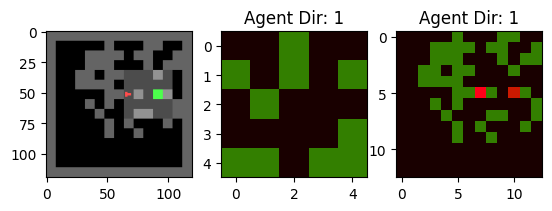

In [82]:
pro_env_state = pro_carry[3]

LEVEL_NUM = 7

level = jax.tree_map(lambda x : x[LEVEL_NUM], pro_env_state.env_state)
env_image = env_renderer.render_state(level, env_params)

fig, (ax1,ax2, ax3) = plt.subplots(1, 3)
ax1.imshow(env_image)

ax2.imshow(pro_traj[0].image[-1, LEVEL_NUM])
ax2.set_title(f"Agent Dir: {pro_traj[0].agent_dir[-1, LEVEL_NUM]}");

ax3.imshow(pro_full_observations.image[-1, LEVEL_NUM])
ax3.set_title(f"Agent Dir: {pro_full_observations.agent_dir[-1, LEVEL_NUM]}");

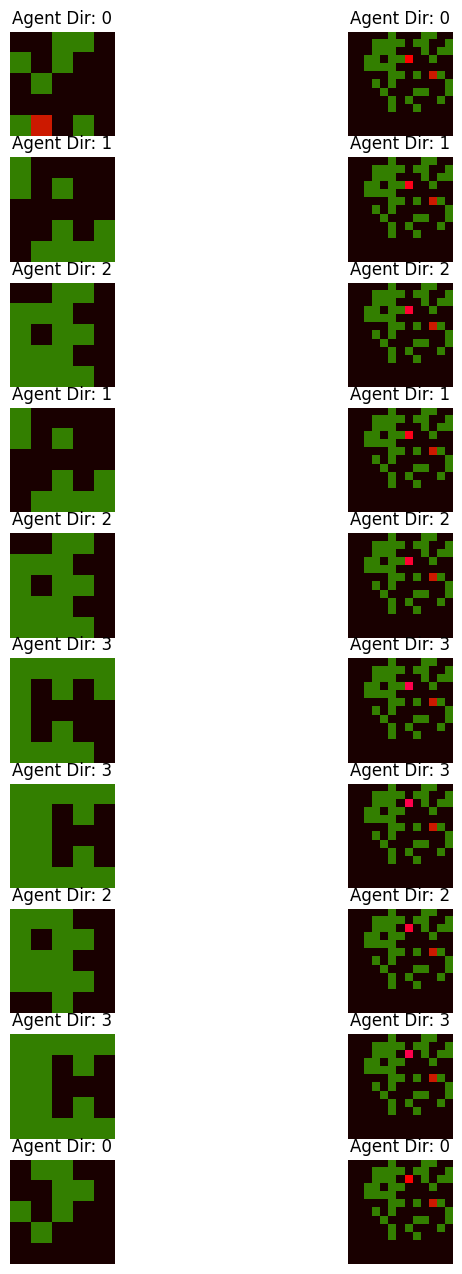

In [83]:
fig, axes = plt.subplots(10, 2, figsize=(8, 16))

for i, (ax1, ax2) in enumerate(axes):
    ax1.imshow(pro_traj[0].image[i, LEVEL_NUM])
    ax1.set_title(f"Agent Dir: {pro_traj[0].agent_dir[i, LEVEL_NUM]}");
    ax1.axis("off")

    ax2.imshow(pro_full_observations.image[i, LEVEL_NUM])
    ax2.set_title(f"Agent Dir: {pro_full_observations.agent_dir[i, LEVEL_NUM]}");
    ax2.axis("off")

In [ ]:
env_renderer.render_state

In [54]:
jnp.arange(256)[pro_traj[3][:,3]]

Array([ 95, 122], dtype=int32)

In [44]:
pro_mean_returns

Array([0.        , 0.        , 0.649     , 0.7786    , 0.        ,
       0.        , 0.        , 0.24759996, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.7012    , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.87399995,
       0.        , 0.        , 0.        , 0.35919994, 0.        ,
       0.84735996, 0.        , 0.        , 0.57519996, 0.22239995,
       0.8852499 , 0.        , 0.        , 0.        , 0.784     ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.694     , 0.        , 0.77559996, 0.334     , 0.        ,
       0.        , 0.        , 0.        , 0.9048    , 0.7624    ,
       0.        , 0.        , 0.19719994, 0.        , 0.        ,
       0.41319996, 0.85179996, 0.        , 0.        , 0.9375143 ,
       0.964     , 0.        , 0.        , 0.        , 0.        ,
       0.7768    , 0.        , 0.        , 0.        , 0.     

In [62]:
agent_regret[:, 3][:123].sum()

Array(58.5, dtype=float32)

In [61]:
1 - 0.9*3/250 - 0.2106

0.7786

In [30]:
pro_traj[3][:, 2][:30]

Array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,  True], dtype=bool)

In [56]:
agent_optimal_distances[0][3]

Array(3., dtype=float32, weak_type=True)

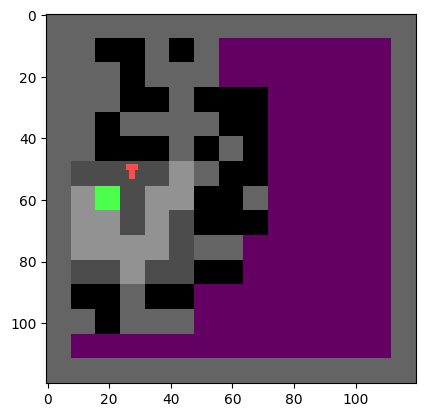

In [57]:
adv_last_env_state = adv_carry[3]
level = jax.tree_map(lambda x : x[3], adv_last_env_state.level)
env_image = adv_env_renderer.render_state(level, adv_env_params)
plt.imshow(env_image)

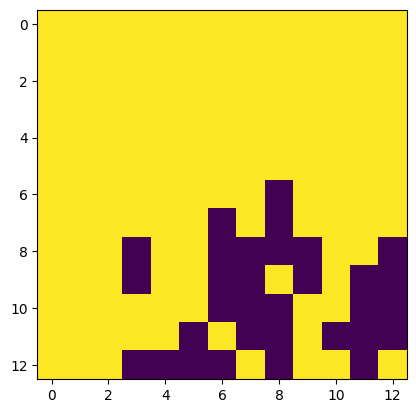

In [170]:
plt.imshow(jnp.logical_or(level.wall_map, ~level.observation_map))

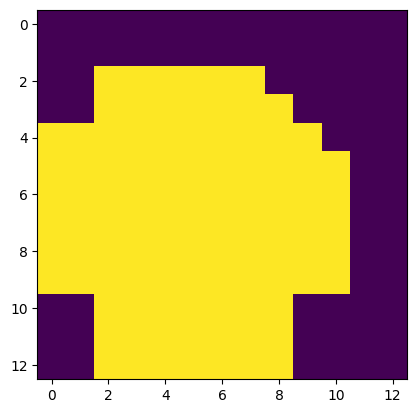

In [149]:
plt.imshow()

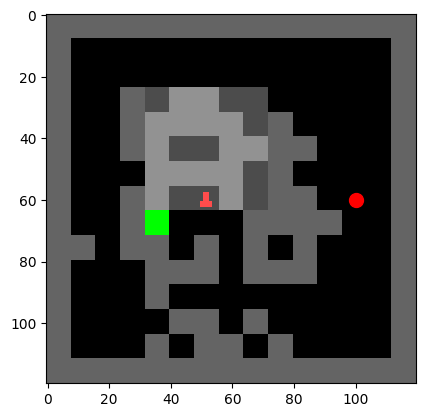

In [88]:
y_val, x_val = 11, 6
plt.imshow(env_image)
plt.plot((y_val + 1.5)*120/15, (x_val + 1.5)*120/15, 'r.', markersize=20)

In [96]:
agent_regret.shape

(256, 128)

In [95]:
adv_traj_idx_array.shape


(256, 128)

In [147]:
120/15

8.0